In [32]:
import numpy as np
import pandas as pd

In [33]:
npy_path = "outputs/diffusion_pt_mg_signal_unfold/unfold_diffusion_lepqua_CT14lo.npy"
csv_path = npy_path.replace(".npy", ".csv")

# Load .npy file
data = np.load(npy_path)

# Wrap into DataFrame (adds column names if you like)
n_cols = data.shape[1]
columns = [f"col_{i}" for i in range(n_cols)]
df = pd.DataFrame(data, columns=columns)
df.drop(columns=["col_0"], inplace=True)

# Rename columns
df.columns = [
    "p_v_1_E_diffusion",
    "p_v_1_x_diffusion",
    "p_v_1_y_diffusion",
    "p_v_1_z_diffusion",
    "p_v_2_E_diffusion",
    "p_v_2_x_diffusion",
    "p_v_2_y_diffusion",
    "p_v_2_z_diffusion",
]

# Save to CSV
df.to_csv(csv_path, index=False)

print(f"Saved: {csv_path}")
df.head()

Saved: outputs/diffusion_pt_mg_signal_unfold/unfold_diffusion_lepqua_CT14lo.csv


,p_v_1_E_diffusion,p_v_1_x_diffusion,p_v_1_y_diffusion,p_v_1_z_diffusion,p_v_2_E_diffusion,p_v_2_x_diffusion,p_v_2_y_diffusion,p_v_2_z_diffusion
0,199.197485,-37.806165,4.387502,193.929917,45.644817,-3.696850,11.163363,45.607357
1,78.505100,-35.501432,31.907471,-60.601710,12.023726,8.981765,8.857880,4.269781
2,46.593317,21.666571,27.572858,32.671235,75.275492,6.364159,23.283503,71.654043
3,262.641665,43.256521,5.468262,264.872074,82.517188,7.101968,3.963915,85.229829
4,54.636477,-21.759561,31.782936,-36.599522,30.397998,-7.676554,22.235942,-19.203137


In [34]:
# Load truth data
truth_data = pd.read_csv("data/hww_sherpa_1M_MG_final_truth_cuts.csv")

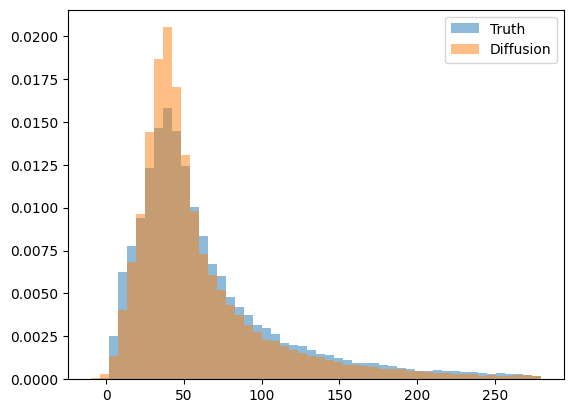

In [35]:
# Plot comparison of neutrinos of truth and diffusion
import matplotlib.pyplot as plt

plt.hist(truth_data["p_v_1_E_truth"], bins=50, alpha=0.5, label="Truth", range=(-10, 280), density=True)
plt.hist(df["p_v_1_E_diffusion"], bins=50, alpha=0.5, label="Diffusion", range=(-10, 280), density=True)
plt.legend()
plt.show()

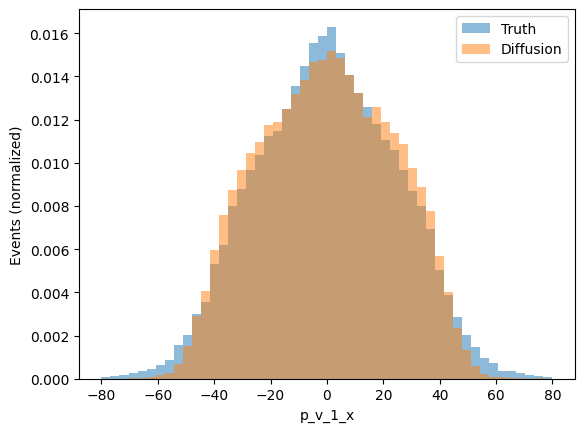

In [42]:
plt.hist(truth_data["p_v_1_x_truth"], bins=50, alpha=0.5, label="Truth", range=(-80, 80), density=True)
plt.hist(df["p_v_1_x_diffusion"], bins=50, alpha=0.5, label="Diffusion", range=(-80, 80), density=True)
plt.legend()
plt.xlabel("p_v_1_x")
plt.ylabel("Events (normalized)")
plt.show()

In [37]:
# Calculate component wise maen absolute error
mae_x = np.mean(np.abs(truth_data["p_v_1_x_truth"] - df["p_v_1_x_diffusion"]), axis=0)
mae_y = np.mean(np.abs(truth_data["p_v_1_y_truth"] - df["p_v_1_y_diffusion"]))
mae_z = np.mean(np.abs(truth_data["p_v_1_z_truth"] - df["p_v_1_z_diffusion"]))
mae_E = np.mean(np.abs(truth_data["p_v_1_E_truth"] - df["p_v_1_E_diffusion"]))
print(f"Mean Absolute Error (p_v_1_x): {mae_x}")
print(f"Mean Absolute Error (p_v_1_y): {mae_y}")
print(f"Mean Absolute Error (p_v_1_z): {mae_z}")
print(f"Mean Absolute Error (p_v_1_E): {mae_E}")

mae_x2 = np.mean(np.abs(truth_data["p_v_2_x_truth"] - df["p_v_2_x_diffusion"]))
mae_y2 = np.mean(np.abs(truth_data["p_v_2_y_truth"] - df["p_v_2_y_diffusion"]))
mae_z2 = np.mean(np.abs(truth_data["p_v_2_z_truth"] - df["p_v_2_z_diffusion"]))
mae_E2 = np.mean(np.abs(truth_data["p_v_2_E_truth"] - df["p_v_2_E_diffusion"]))
print(f"Mean Absolute Error (p_v_2_x): {mae_x2}")
print(f"Mean Absolute Error (p_v_2_y): {mae_y2}")
print(f"Mean Absolute Error (p_v_2_z): {mae_z2}")
print(f"Mean Absolute Error (p_v_2_E): {mae_E2}")

Mean Absolute Error (p_v_1_x): 15.415959913259911
Mean Absolute Error (p_v_1_y): 15.406709252344436
Mean Absolute Error (p_v_1_z): 58.840254767588085
Mean Absolute Error (p_v_1_E): 48.322428025729394
Mean Absolute Error (p_v_2_x): 13.314065143803102
Mean Absolute Error (p_v_2_y): 13.240713004669374
Mean Absolute Error (p_v_2_z): 39.38467484888934
Mean Absolute Error (p_v_2_E): 34.018681852923535


In [38]:
print(np.mean([mae_x, mae_y, mae_z, mae_E, mae_x2, mae_y2, mae_z2, mae_E2]))

29.742935851150897


In [39]:
# Load ww and hww and compare
ww_data = pd.read_csv("data/hww_sherpa_1M_MG_final_truth_cuts.csv")[:200000]
hww_data = pd.read_csv("data/hww_1M_MG_final_truth_cuts.csv")[:200000]

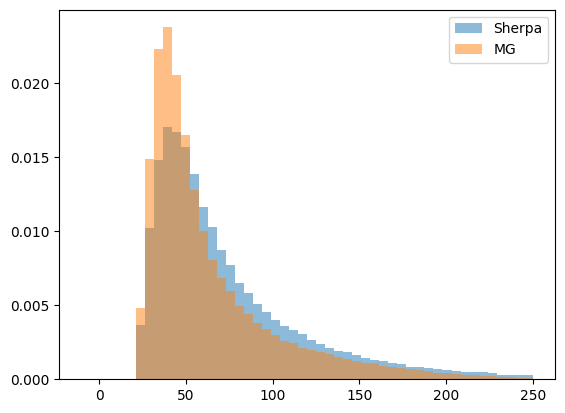

In [40]:
# Plot 1d hist of ww/hww
plt.hist(ww_data["p_l_1_E_truth"], bins=50, alpha=0.5, label="Sherpa", range=(-10, 250), density=True)
plt.hist(hww_data["p_l_1_E_truth"], bins=50, alpha=0.5, label="MG", range=(-10, 250), density=True)
plt.legend()
plt.show()

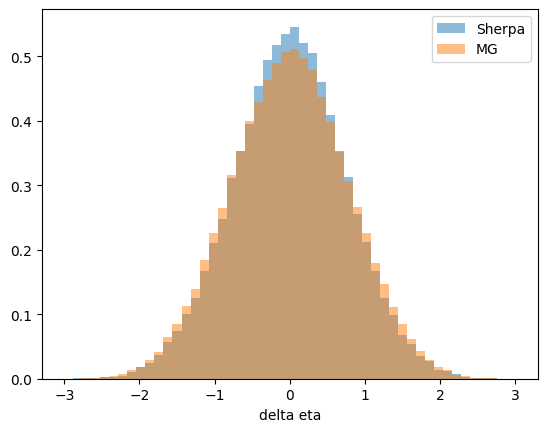

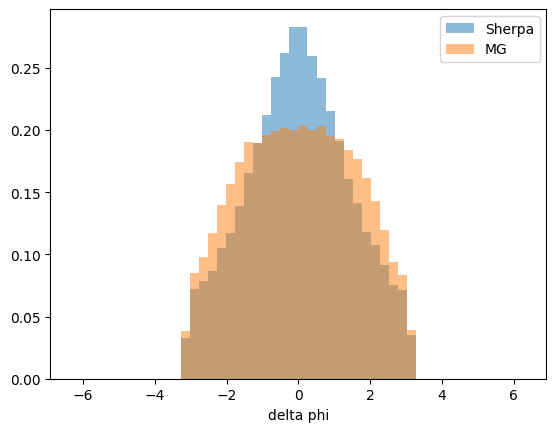

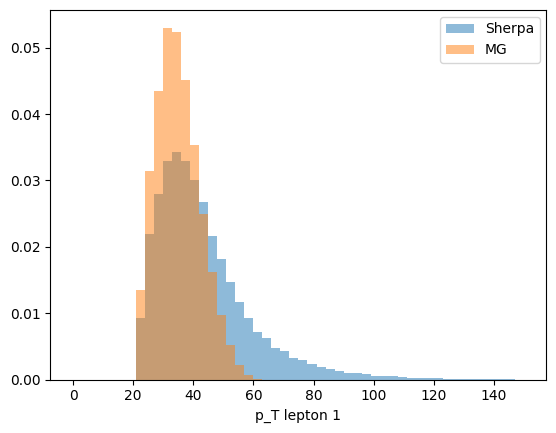

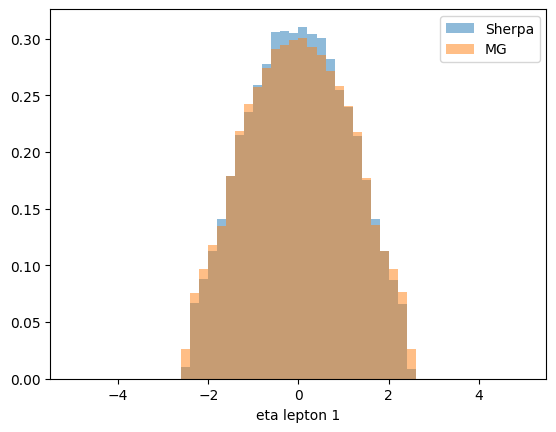

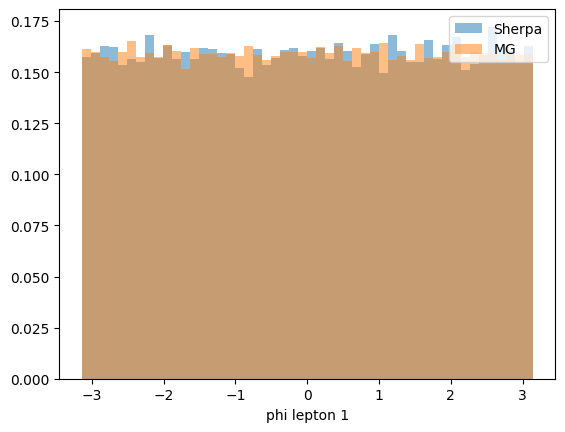

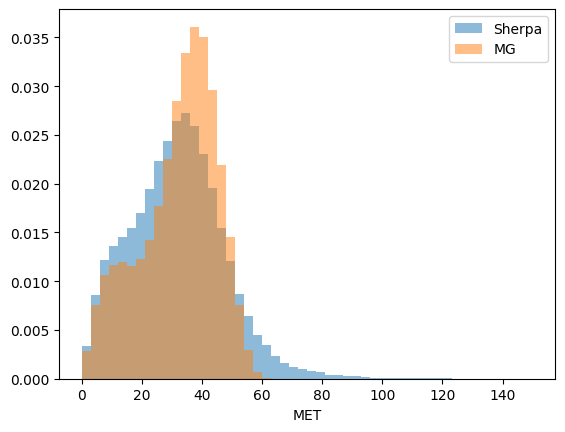

In [41]:
# Calculate transverse momentum for WW and HWW truth
p_T_ww = np.sqrt(ww_data["p_l_1_x_truth"]**2 + ww_data["p_l_1_y_truth"]**2)
p_T_hww = np.sqrt(hww_data["p_l_1_x_truth"]**2 + hww_data["p_l_1_y_truth"]**2)

# Compute eta
p_norm_ww1 = np.sqrt(ww_data["p_l_1_x_truth"]**2 + ww_data["p_l_1_y_truth"]**2 + ww_data["p_l_1_z_truth"]**2)
eta_ww1 = 0.5 * np.log((p_norm_ww1 + ww_data["p_l_1_z_truth"]) / (p_norm_ww1 - ww_data["p_l_1_z_truth"] + 1e-15))
p_norm_ww2 = np.sqrt(ww_data["p_l_2_x_truth"]**2 + ww_data["p_l_2_y_truth"]**2 + ww_data["p_l_2_z_truth"]**2)
eta_ww2 = 0.5 * np.log((p_norm_ww2 + ww_data["p_l_2_z_truth"]) / (p_norm_ww2 - ww_data["p_l_2_z_truth"] + 1e-15))

delta_eta_ww = eta_ww1 - eta_ww2

p_norm_hww1 = np.sqrt(hww_data["p_l_1_x_truth"]**2 + hww_data["p_l_1_y_truth"]**2 + hww_data["p_l_1_z_truth"]**2)
eta_hww1 = 0.5 * np.log((p_norm_hww1 + hww_data["p_l_1_z_truth"]) / (p_norm_hww1 - hww_data["p_l_1_z_truth"] + 1e-15))
p_norm_hww2 = np.sqrt(hww_data["p_l_2_x_truth"]**2 + hww_data["p_l_2_y_truth"]**2 + hww_data["p_l_2_z_truth"]**2)
eta_hww2 = 0.5 * np.log((p_norm_hww2 + hww_data["p_l_2_z_truth"]) / (p_norm_hww2 - hww_data["p_l_2_z_truth"] + 1e-15))
delta_eta_hww = eta_hww1 - eta_hww2

# Plot delta eta comparison
plt.hist(delta_eta_ww, bins=50, alpha=0.5, label="Sherpa", range=(-3, 3), density=True)
plt.hist(delta_eta_hww, bins=50, alpha=0.5, label="MG", range=(-3, 3), density=True)
plt.xlabel("delta eta")
plt.legend()
plt.show()

# Compute phi for WW truth and HWW truth
phi_ww = np.arctan2(ww_data["p_l_1_y_truth"], ww_data["p_l_1_x_truth"])
phi_hww = np.arctan2(hww_data["p_l_1_y_truth"], hww_data["p_l_1_x_truth"])

delta_phi_ww = np.arctan2(ww_data["p_l_1_y_truth"], ww_data["p_l_1_x_truth"]) - np.arctan2(ww_data["p_l_2_y_truth"], ww_data["p_l_2_x_truth"])
delta_phi_hww = np.arctan2(hww_data["p_l_1_y_truth"], hww_data["p_l_1_x_truth"]) - np.arctan2(hww_data["p_l_2_y_truth"], hww_data["p_l_2_x_truth"])
delta_phi_hww = (delta_phi_hww + np.pi) % (2 * np.pi) - np.pi
delta_phi_ww = (delta_phi_ww + np.pi) % (2 * np.pi) - np.pi

# Plot delta phi comparison
plt.hist(delta_phi_ww, bins=50, alpha=0.5, label="Sherpa", range=(-2 * np.pi, 2 * np.pi), density=True)
plt.hist(delta_phi_hww, bins=50, alpha=0.5, label="MG", range=(-2 * np.pi, 2 * np.pi), density=True)
plt.xlabel("delta phi")
plt.legend()
plt.show()


# Plot p_T comparison
plt.hist(p_T_ww, bins=50, alpha=0.5, label="Sherpa", range=(0, 150), density=True)
plt.hist(p_T_hww, bins=50, alpha=0.5, label="MG", range=(0, 150), density=True)
plt.xlabel("p_T lepton 1")
plt.legend()
plt.show()

# Plot eta comparison
plt.hist(eta_ww1, bins=50, alpha=0.5, label="Sherpa", range=(-5, 5), density=True)
plt.hist(eta_hww1, bins=50, alpha=0.5, label="MG", range=(-5, 5), density=True)
plt.xlabel("eta lepton 1")
plt.legend()
plt.show()

# Plot phi comparison
plt.hist(phi_ww, bins=50, alpha=0.5, label="Sherpa", range=(-np.pi, np.pi), density=True)
plt.hist(phi_hww, bins=50, alpha=0.5, label="MG", range=(-np.pi, np.pi), density=True)
plt.xlabel("phi lepton 1")
plt.legend()
plt.show()

met_ww = np.sqrt(ww_data["p_v_1_x_truth"]**2 + ww_data["p_v_1_y_truth"]**2)
met_hww = np.sqrt(hww_data["p_v_1_x_truth"]**2 + hww_data["p_v_1_y_truth"]**2)

# Plot met comparison
plt.hist(met_ww, bins=50, alpha=0.5, label="Sherpa", range=(0, 150), density=True)
plt.hist(met_hww, bins=50, alpha=0.5, label="MG", range=(0, 150), density=True)
plt.xlabel("MET")
plt.legend()
plt.show()